<a href="https://colab.research.google.com/github/sindla97/Machine-Learning/blob/main/census_bureau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
columns=pd.read_csv('/content/census-bureau.columns',sep=',',names=['columns'])
columns['columns']=columns['columns'].str.replace(' ','_')
columns

,columns
0,age
1,class_of_worker
2,detailed_industry_recode
3,detailed_occupation_recode
4,education
5,wage_per_hour
6,enroll_in_edu_inst_last_wk
7,marital_stat
8,major_industry_code
9,major_occupation_code


In [110]:
df=pd.read_csv('/content/census-bureau.data', sep=",",names=columns['columns'].tolist())
df.head()

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veteran's_admin,veterans_benefits,weeks_worked_in_year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [163]:
#found missing values in hispanic_origin	column <1%
df.isna().sum().reset_index(name='p').sort_values(by='p',ascending=False)

,index,p
0,age,0
1,class_of_worker,0
2,detailed_industry_recode,0
3,detailed_occupation_recode,0
4,education,0
5,wage_per_hour,0
6,enroll_in_edu_inst_last_wk,0
7,marital_stat,0
8,major_industry_code,0
9,major_occupation_code,0


In [162]:
#imputing with the most popular category
df['hispanic_origin']=np.where(df['hispanic_origin'].isna(),'All other', df['hispanic_origin'])

In [111]:
df['detailed_occupation_recode']=df['detailed_occupation_recode'].astype('object')
df['detailed_industry_recode']=df['detailed_industry_recode'].astype('object')
df['veterans_benefits']=df['veterans_benefits'].astype('int').astype('object')
df['own_business_or_self_employed']=df['own_business_or_self_employed'].astype('int').astype('object')


In [99]:
df.shape

(199523, 42)

In [112]:
df['label']=df['label'].apply(lambda x: 1 if x=='50000+.' else 0)
# df['label']=df['label'].astype('category')

In [117]:
df['label'].value_counts()

,count
label,
0,187141
1,12382


In [ ]:
df.groupby('label')['weight'].mean()

,weight
label,
0,1730.635250
1,1789.411021


In [118]:
(df.groupby('label')['weight'].sum()/df['weight'].sum())*100

,weight
label,
0,93.594958
1,6.405042


In [ ]:
unique_cnt=[]
data_type_df=df.dtypes.reset_index(name='data_type')
data_type_df

for i in data_type_df['index'].tolist():
  #print(data_type_df.loc[data_type_df['index']==i,'data_type'])
  if data_type_df.loc[data_type_df['index'] == i, 'data_type'].iloc[0] == 'object':
    unique_cnt.append(df[i].nunique())
  else: unique_cnt.append(0)
#print(unique_cnt)
data_type_df['nunique']=pd.Series(unique_cnt)
data_type_df

# df['class_of_worker'].unique().tolist()

,index,data_type,nunique
0,age,int64,0
1,class_of_worker,object,9
2,detailed_industry_recode,object,52
3,detailed_occupation_recode,object,47
4,education,object,17
5,wage_per_hour,int64,0
6,enroll_in_edu_inst_last_wk,object,3
7,marital_stat,object,7
8,major_industry_code,object,24
9,major_occupation_code,object,15


(array([13.,  8.,  1.,  1.,  1.,  0.,  1.,  0.,  3.,  3.]),
 array([ 2. ,  6.9, 11.8, 16.7, 21.6, 26.5, 31.4, 36.3, 41.2, 46.1, 51. ]),
 <BarContainer object of 10 artists>)

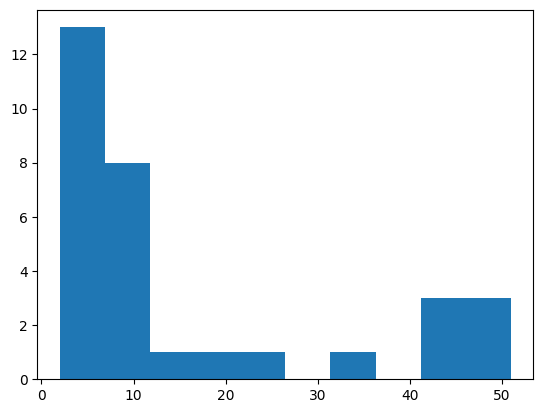

In [ ]:
import matplotlib.pyplot as plt
plt.hist(data_type_df.loc[data_type_df['data_type']=='object',['nunique']])
# data_type_df.loc[data_type_df['data_type']=='object',['nunique']].plot.density()

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

v_father_mother = cramers_v(df['country_of_birth_father'], df['country_of_birth_mother'])
v_father_self   = cramers_v(df['country_of_birth_father'], df['country_of_birth_self'])
v_mother_self   = cramers_v(df['country_of_birth_mother'], df['country_of_birth_self'])
print(f'v_father_mother:{v_father_mother}; v_father_self:{v_father_self}; v_mother_self:{v_mother_self}' )

v_father_mother:0.7736623864330392; v_father_self:0.6737821673082836; v_mother_self:0.6975523224864765


In [ ]:
target='label'
sample_weight='weight'
cat_l_cardinal_col= [x for x in data_type_df.loc[(data_type_df['data_type']=='object') &(data_type_df['nunique']<=4),'index'].tolist() if x not in [target,sample_weight]]
cat_h_cardinal_col= [x for x in data_type_df.loc[data_type_df['data_type']=='object','index'].tolist() if x not in [target,sample_weight]+cat_l_cardinal_col]
int_columns= [x for x in data_type_df.loc[data_type_df['data_type']=='int64','index'].tolist() if x not in [target,sample_weight]]
print(len(cat_l_cardinal_col), len(cat_h_cardinal_col), len(int_columns))

8 24 8


In [ ]:
[x for x in df.columns if x not in cat_l_cardinal_col+cat_h_cardinal_col+int_columns]

['weight', 'label']

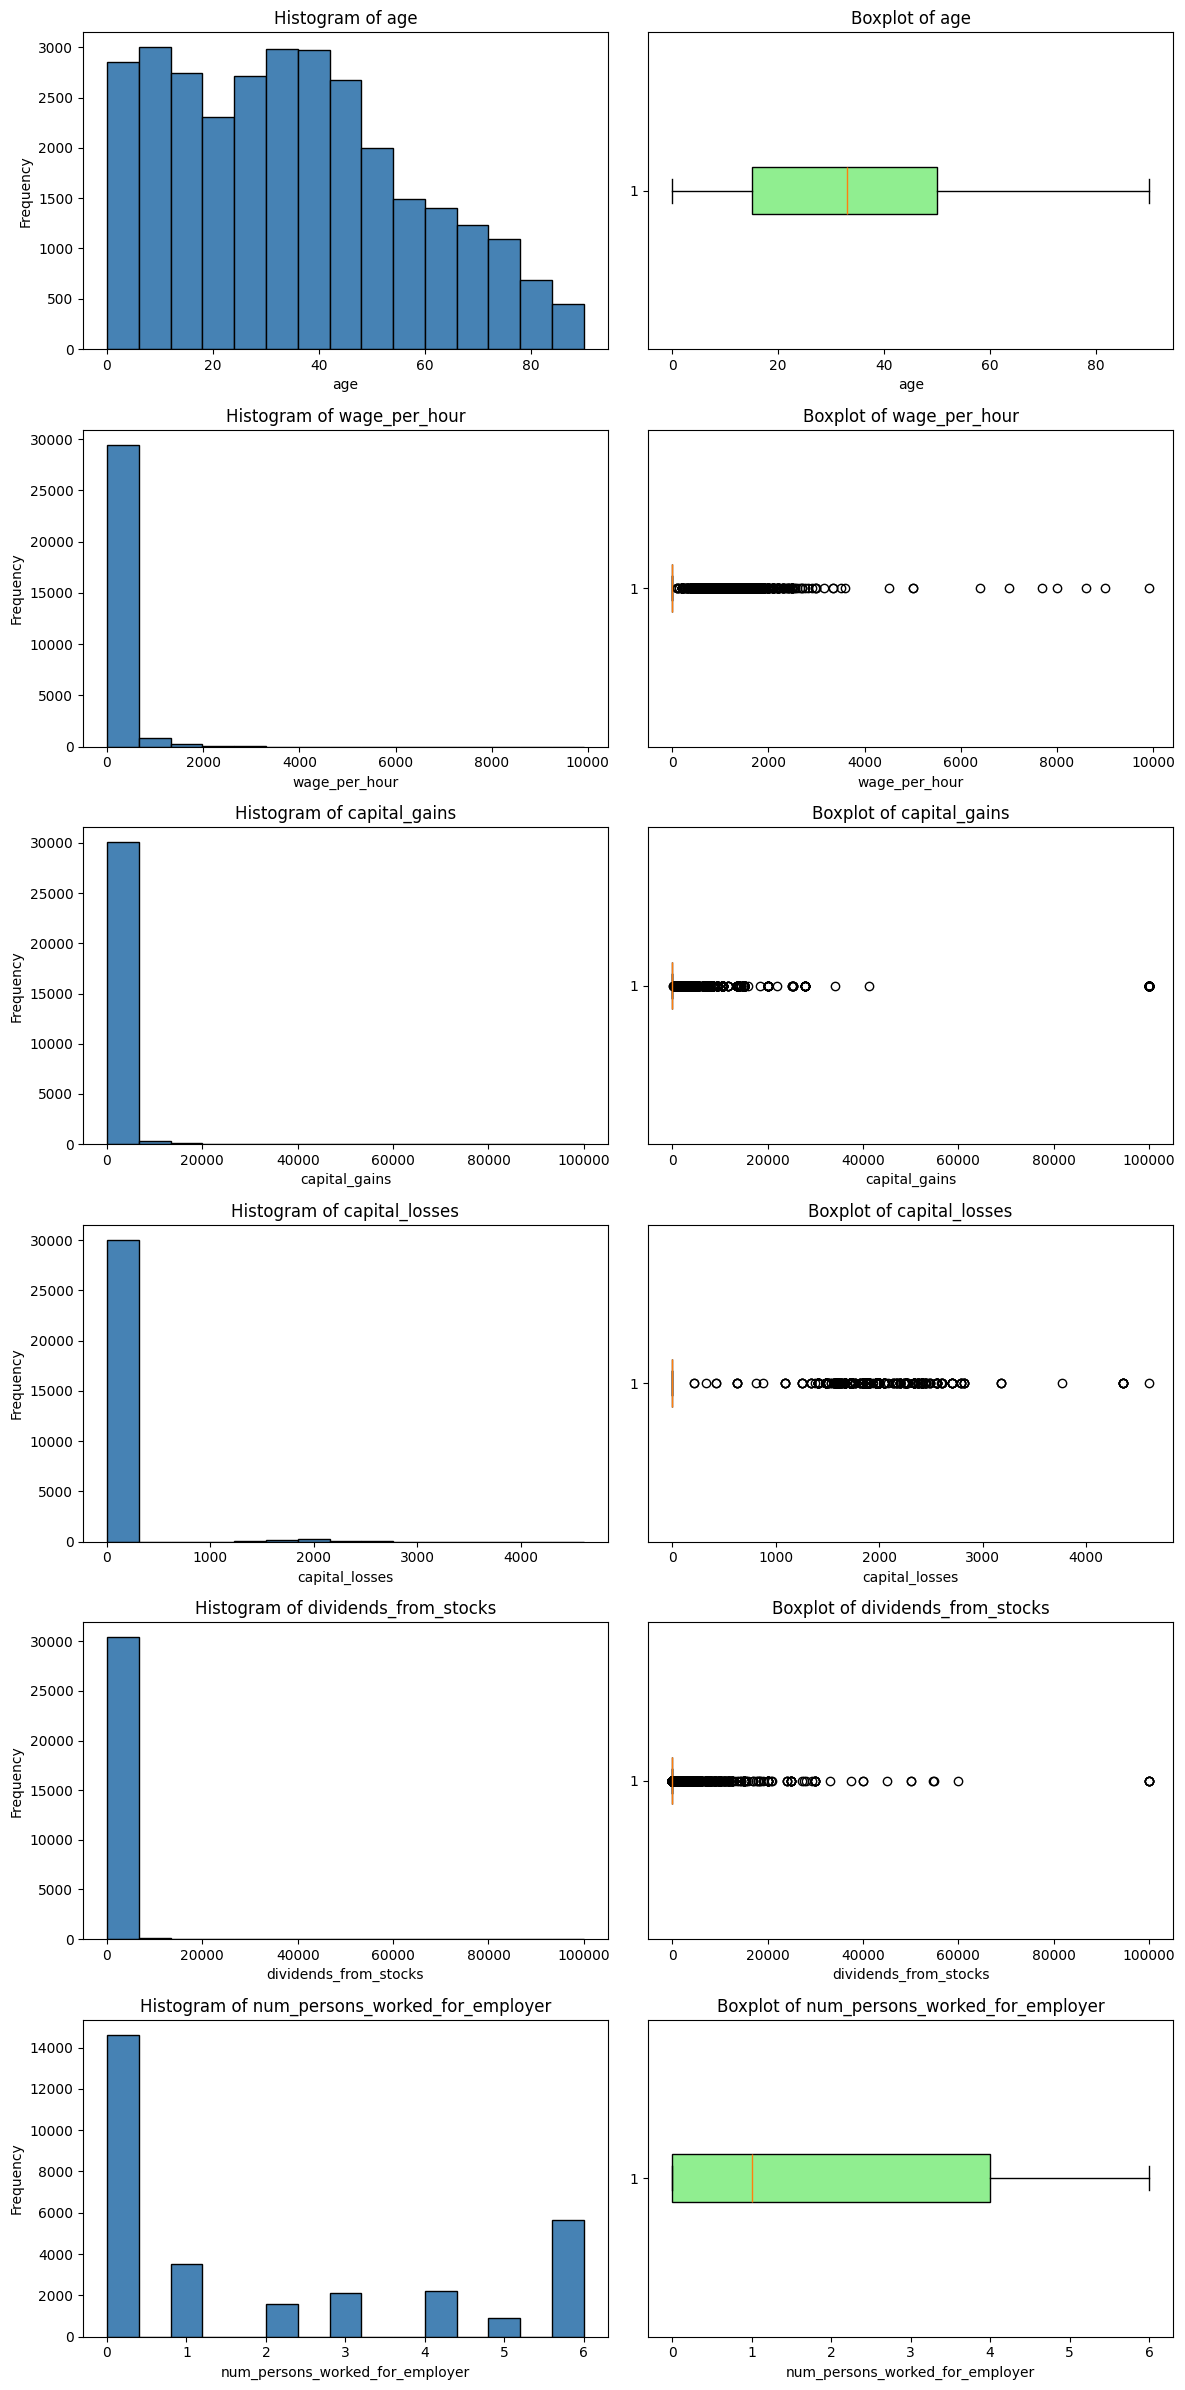

In [ ]:
n = len(int_columns)   # number of integer features

# Create the figure and axes
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

# Loop through each integer column
for i, col in enumerate(int_columns):
    axes[i, 0].hist(df[col], bins=15, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    axes[i, 1].boxplot(df[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', color='black'))
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

In [113]:
df.replace({'?': 'unknown'}, inplace=True)


In [ ]:
cat_feat_exp = pd.DataFrame()

for i in cat_h_cardinal_col:
  v_counts=df[i].value_counts().reset_index(name='value_counts').rename(columns={f'{i}':'values'})
  v_counts['value_counts_percent']=(v_counts['value_counts']/df.shape[0])*100
  v_meantarget=df.groupby(i)[target].mean().reset_index(name='meantarget').rename(columns={f'{i}':'values'})
  merge_df=v_counts.merge(v_meantarget, on='values', how='left')
  merge_df['feature']=i
  cat_feat_exp=pd.concat([cat_feat_exp,merge_df], axis=0,ignore_index=True)
cat_feat_exp


,values,value_counts,value_counts_percent,meantarget,feature
0,Not in universe,100245,50.242328,0.009018,class_of_worker
1,Private,72028,36.100099,0.101655,class_of_worker
2,Self-employed-not incorporated,8445,4.232595,0.129070,class_of_worker
3,Local government,7784,3.901305,0.108813,class_of_worker
4,State government,4227,2.118553,0.114739,class_of_worker
...,...,...,...,...,...
471,Native- Born in the United States,176992,88.707568,0.062992,citizenship
472,Foreign born- Not a citizen of U S,13401,6.716519,0.036714,citizenship
473,Foreign born- U S citizen by naturalization,5855,2.934499,0.099061,citizenship
474,Native- Born abroad of American Parent(s),1756,0.880099,0.072893,citizenship


In [114]:
hcard_converge=cat_feat_exp[((cat_feat_exp['value_counts_percent']<=10)&(cat_feat_exp['meantarget']<=0.07)) |((cat_feat_exp['value_counts_percent']<=0.05) &(cat_feat_exp['meantarget']<=0.5))]



In [115]:
for i in cat_h_cardinal_col:
  comp_cat = hcard_converge.loc[hcard_converge['feature'] == i, 'values'].tolist()

  df[i] = df[i].where(~df[i].isin(comp_cat), 'other')
  # print(df[i].value_counts())

class_of_worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
other                                604
Name: count, dtype: int64
detailed_industry_recode
0        100684
other     33983
43         8283
4          5984
42         4683
45         4482
29         4209
37         4022
41         3964
32         3596
35         3380
34         2765
11         1764
50         1704
47         1644
24         1503
12         1350
30         1181
31         1178
25         1084
9           993
13          899
48          652
27          626
49          610
3           563
8           550
16          539
23          525
18          483
15          452
7           422
14          295
46          187
17          157
26          127
Name: count, dtype: int64
det

In [159]:
cat_feat_exp[cat_feat_exp['feature']=='hispanic_origin']

,values,value_counts,value_counts_percent,meantarget,feature
176,All other,171907,86.158989,0.068450,hispanic_origin
177,Mexican-American,8079,4.049157,0.021290,hispanic_origin
178,Mexican (Mexicano),7234,3.625647,0.011335,hispanic_origin
179,Central or South American,3895,1.952156,0.020539,hispanic_origin
180,Puerto Rican,3313,1.660460,0.020525,hispanic_origin
181,Other Spanish,2485,1.245470,0.032596,hispanic_origin
182,Cuban,1126,0.564346,0.054174,hispanic_origin
183,Do not know,306,0.153366,0.026144,hispanic_origin
184,Chicano,304,0.152363,0.019737,hispanic_origin


In [116]:
cat_feat_exp[(cat_feat_exp['feature']=='country_of_birth_self') &(cat_feat_exp['values']=='Hong Kong')]

,values,value_counts,value_counts_percent,meantarget,feature
463,Hong Kong,100,0.05012,0.1,country_of_birth_self


In [128]:
df[int_columns].describe()

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,weeks_worked_in_year,year
count,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,0.381997,0.320614,0.147192,0.604961,1.956180,23.174897,94.499672
std,22.310895,1.563578,1.648662,1.042446,1.885123,2.365126,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8.000000,94.000000
75%,50.000000,0.000000,0.000000,0.000000,0.000000,4.000000,52.000000,95.000000
max,90.000000,9.210340,11.512925,8.435766,11.512925,6.000000,52.000000,95.000000


In [127]:
for i in int_columns:
  if i in ['wage_per_hour','capital_gains','capital_losses','dividends_from_stocks']:
    df[i]=np.where(df[i]==0,0, np.log1p(df[i]))


In [134]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(df[['age']], df['label'])
print(mi)

[0.03795227]


In [164]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    random_state=42,
test_size=0.3,stratify=df[target])

In [165]:
print(train_df[target].value_counts(), test_df[target].value_counts())

label
0    130999
1      8667
Name: count, dtype: int64 label
0    56142
1     3715
Name: count, dtype: int64


In [138]:
import warnings
warnings.filterwarnings('ignore')

In [166]:
global_mean = train_df[target].mean()

for feature in cat_h_cardinal_col:

  mean_map = train_df.groupby(feature)[target].mean()


  train_df[f'{feature}_enc_mt'] = train_df[feature].map(mean_map)
  test_df[f'{feature}_enc_mt']  = test_df[feature].map(mean_map)

  pop_map = train_df[feature].value_counts()/train_df.shape[0]
  train_df[f'{feature}_enc_pop'] = train_df[feature].map(pop_map)
  test_df[f'{feature}_enc_pop']  = test_df[feature].map(pop_map)

# Handle unknown categories in test
  test_df[f'{feature}_enc_mt'].fillna(global_mean, inplace=True)
  test_df[f'{feature}_enc_pop'].fillna(global_mean, inplace=True)

In [140]:
train_df.describe()

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,weight,num_persons_worked_for_employer,own_business_or_self_employed,veterans_benefits,weeks_worked_in_year,...,family_members_under_18_enc_mt,family_members_under_18_enc_pop,country_of_birth_father_enc_mt,country_of_birth_father_enc_pop,country_of_birth_mother_enc_mt,country_of_birth_mother_enc_pop,country_of_birth_self_enc_mt,country_of_birth_self_enc_pop,citizenship_enc_mt,citizenship_enc_pop
count,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,...,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000
mean,34.468983,0.383485,0.321683,0.148939,0.605584,1740.683954,1.955050,0.176063,1.513640,23.152614,...,0.062055,0.566402,0.062055,0.650789,0.062055,0.661364,0.062055,0.790629,0.062055,0.792639
std,22.315965,1.566097,1.652333,1.048657,1.887546,994.066463,2.365581,0.554511,0.852232,24.405993,...,0.038487,0.252320,0.016423,0.290001,0.016325,0.287776,0.014415,0.268435,0.009840,0.262831
min,0.000000,0.000000,0.000000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.082268,0.024439,0.000580,0.025158,0.000945,0.021926,0.000444,0.035190,0.008706
25%,15.000000,0.000000,0.000000,0.000000,0.000000,1061.570000,0.000000,0.000000,2.000000,0.000000,...,0.000037,0.195695,0.064790,0.796772,0.064816,0.803302,0.063000,0.886579,0.062999,0.886594
50%,33.000000,0.000000,0.000000,0.000000,0.000000,1617.895000,1.000000,0.000000,2.000000,8.000000,...,0.085935,0.722037,0.064790,0.796772,0.064816,0.803302,0.063000,0.886579,0.062999,0.886594
75%,50.000000,0.000000,0.000000,0.000000,0.000000,2189.980000,4.000000,0.000000,2.000000,52.000000,...,0.085935,0.722037,0.064790,0.796772,0.064816,0.803302,0.063000,0.886579,0.062999,0.886594
max,90.000000,9.210340,11.512925,8.435766,11.512925,18656.300000,6.000000,2.000000,2.000000,52.000000,...,0.085935,0.722037,0.140436,0.796772,0.151515,0.803302,0.186916,0.886579,0.099347,0.886594


In [ ]:
#Linear model
#1. combine all features remove the original high cardinal categorical features and repalce with encoded features
#2. perfrom standard scalar
#3. one hot encode and retain the low cardinal (<=4 categories) fetaures.
#calcualte the class weights
# use sample_weights
# train model

In [167]:
cat_l_cardinal_col_encoded=[]
from sklearn.preprocessing import OneHotEncoder
for i in cat_l_cardinal_col:
# i='enroll_in_edu_inst_last_wk'
  oe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


  train_encoded = oe.fit_transform(train_df[[i]])

  test_encoded = oe.transform(test_df[[i]])

  encoded_cols = oe.get_feature_names_out([i])

  train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_df.index)
  test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_df.index)

  train_df = pd.concat([train_df, train_encoded_df], axis=1)
  test_df = pd.concat([test_df, test_encoded_df], axis=1)
  cat_l_cardinal_col_encoded.extend(encoded_cols)


In [168]:
final_features_lr=[x for x in int_columns if x not in ['year']]+cat_l_cardinal_col_encoded+[ f'{x}_enc_mt' for x in cat_h_cardinal_col]+[f'{x}_enc_pop' for x in cat_h_cardinal_col]
final_features_lr

['age',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'num_persons_worked_for_employer',
 'weeks_worked_in_year',
 'enroll_in_edu_inst_last_wk_College or university',
 'enroll_in_edu_inst_last_wk_High school',
 'enroll_in_edu_inst_last_wk_Not in universe',
 'sex_Female',
 'sex_Male',
 'member_of_a_labor_union_No',
 'member_of_a_labor_union_Not in universe',
 'member_of_a_labor_union_Yes',
 'live_in_this_house_1_year_ago_No',
 'live_in_this_house_1_year_ago_Not in universe under 1 year old',
 'live_in_this_house_1_year_ago_Yes',
 'migration_prev_res_in_sunbelt_No',
 'migration_prev_res_in_sunbelt_Not in universe',
 'migration_prev_res_in_sunbelt_Yes',
 'migration_prev_res_in_sunbelt_unknown',
 'own_business_or_self_employed_0',
 'own_business_or_self_employed_1',
 'own_business_or_self_employed_2',
 "fill_inc_questionnaire_for_veteran's_admin_No",
 "fill_inc_questionnaire_for_veteran's_admin_Not in universe",
 "fill_inc_questionnaire_for_veteran's_adm

In [169]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
train_df_final=ss.fit_transform(train_df[final_features_lr])
test_df_final=ss.transform(test_df[final_features_lr])

In [170]:
train_df.isna().sum().reset_index(name='p').sort_values(by='p',ascending=False)

,index,p
0,age,0
1,class_of_worker,0
2,detailed_industry_recode,0
3,detailed_occupation_recode,0
4,education,0
...,...,...
109,fill_inc_questionnaire_for_veteran's_admin_Not...,0
110,fill_inc_questionnaire_for_veteran's_admin_Yes,0
111,veterans_benefits_0,0
112,veterans_benefits_1,0


## Base model

In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
lr=LogisticRegression(class_weight='balanced' )
lr.fit(train_df_final, train_df[target],sample_weight=train_df[sample_weight])
y_predict=lr.predict(test_df_final)


In [177]:
print(classification_report(test_df[target],y_predict))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     56142
           1       0.70      0.37      0.49      3715

    accuracy                           0.95     59857
   macro avg       0.83      0.68      0.73     59857
weighted avg       0.94      0.95      0.94     59857



In [179]:
print(classification_report(test_df[target],y_predict))

              precision    recall  f1-score   support

           0       0.99      0.85      0.92     56142
           1       0.28      0.89      0.43      3715

    accuracy                           0.85     59857
   macro avg       0.64      0.87      0.67     59857
weighted avg       0.95      0.85      0.88     59857



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    # Regularization strength
    "C": [ 0.01, 0.1, 1, 10],
    "solver": ["saga", "lbfgs"],
    "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
    "max_iter": [ 500, 1000],
    "fit_intercept": [True, False],

}


lr_cv=LogisticRegression(class_weight='balanced',random_state=42,penalty='elasticnet', tol= 1e-4)
random_search = RandomizedSearchCV(
    estimator=lr_cv,
    param_distributions=param_grid,
    cv=2,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=5, n_iter=5
)
random_search.fit(train_df_final, train_df[target],sample_weight=train_df[sample_weight])
y_test_predict_lr_cv=lr.predict(test_df_final)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


In [ ]:
print(classification_report(test_df[target],y_test_predict_lr_cv))

#Boosting model

In [ ]:
final_features_boost=[x for x in int_columns if x not in ['year']]+cat_l_cardinal_col+[ f'{x}_enc_mt' for x in cat_h_cardinal_col]+[f'{x}_enc_pop' for x in cat_h_cardinal_col]
final_features_boost

In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Initialize model
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# Train
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
